<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2025-1/Laboratorios/Laboratorio_04_reg_multivariada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio 05

### 1. Para simular un conjunto de características $x_1$ , $x_2$,..., $x_n$ trabajaremos en la primera parte con dos características de datos aleatorios que presentan un plano y mostraremos que los párametros optimizados se corresponden con el valor esperado.

- Definir la ecuación  $y = 2.1*x_1 - 3.1*x_2$, y generar números aleatorios que pertenecen al plano.

- Realizar un diagrama 3D de los puntos generados aleatoriamente.


Nuestro objetivo será encontrar los valores $\theta_0 = 0, \theta_1=2.1, \theta_1=3.1$ que mejor ajustar el plano, empleando cálculos 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
y = lambda x1, x2: 2.1 * x1  + 3.1 * x2
x1 = np.random.randint(-10, 10, 100)
x2 = np.random.randint(-10, 10, 100)

X1, X2 = np.meshgrid(x1, x2)
Y = y(X1, X2)

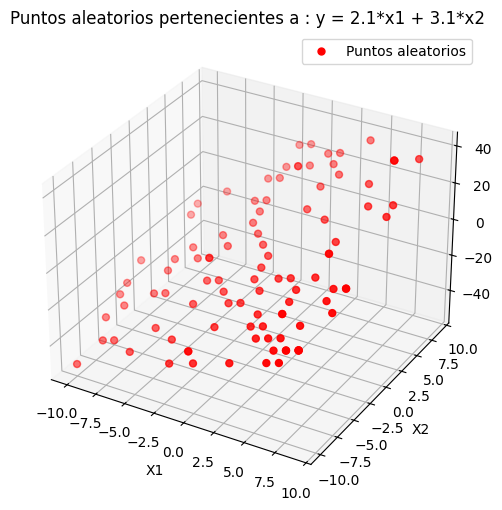

In [22]:
# 3d plot (plano + puntos aleatorios)
X1, X2 = np.meshgrid(x1, x2)
Y = y(X1, X2)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plano
#ax.plot_surface(X1, X2, Y, cmap='viridis', edgecolor='none', alpha=0.65)

# Puntos aleatorios
ax.scatter(x1, x2, y(x1, x2), color='red', s=25, label='Puntos aleatorios')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')
ax.set_title('Puntos aleatorios pertenecientes a : y = 2.1*x1 + 3.1*x2')
ax.legend()
plt.show()

### 2. Inicializar conjunto de parámetros $\Theta$ de manera aleatoria.

In [23]:
thet = np.random.randn(3,1) * np.random.randint(1, 5)
thet

array([[-1.27913129],
       [-0.40936694],
       [-0.89912767]])

### 3. Construir la matrix X con dimensiones $(n+1, m)$, m es el numero de datos de entrenamiento y (n) el número de caracteristicas.

In [24]:
ones = np.ones(100)
X = np.array([ones, x1, x2])
Y = np.array(y(x1, x2)).reshape(1, 100)
X.shape

(3, 100)

In [25]:
Y.shape

(1, 100)

### 4. Calcular la función de coste (revise cuidosamente las dimensiones de cada matriz):
 
  - $h = \Theta^{T} X $
  - $\Lambda= (h -Y) $
  - $\Lambda*= (h -Y)^2 $
  - $\Lambda= [\Lambda_1,\Lambda_2, ...,\Lambda_m]$
  - $J = \frac{1}{2m} \sum_{i}^m \Lambda_i $

In [27]:
thet.T.shape, X.shape

((1, 3), (3, 100))

In [28]:
h = np.dot(thet.T, X)
h.shape

(1, 100)

In [29]:
L = h - Y
L.shape

(1, 100)

In [30]:
L2 = L**2
L2.shape

(1, 100)

In [31]:
m = len(x1)
J = (1/(2*m)) * np.sum(L2)
J.shape

()

### 5. Aplicar el gradiente descendente: 
  - Encontrar el gradiente.
    $\nabla J = \Lambda X.T$
  
  - Actualizar los nuevos parametros: 
    $\Theta_{n+1}=\Theta_{n}-\alpha\nabla J$

In [32]:
grad_J = (1/m) * np.dot(X, L.T)

thet = thet - 0.01 * grad_J

### 6. Iterar para encontrar los valores $\Theta$ que se ajustan el plano.

In [33]:
# gradient descent
alpha = 0.01
num_iters = 10000
m = len(x1)
for i in range(num_iters):
    h = np.dot(thet.T, X)
    L = h - Y
    grad_J = np.dot(X, L.T) / m
    thet = thet - (alpha) * grad_J

In [34]:
thet.round(2)

array([[-0. ],
       [ 2.1],
       [ 3.1]])

### 7. Reescribir su código como una clase

Theta estimado: [-8.91560882e-16  2.10000000e+00  3.10000000e+00]


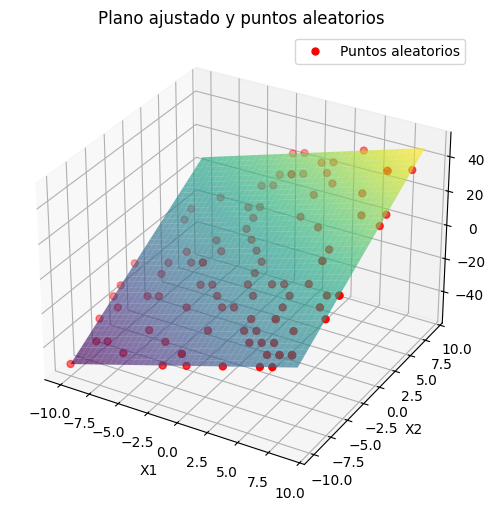

In [36]:
class MultilinearRegresion:
    def __init__(self, X, Y):
        self.X = X                      # (n+1, m)
        self.Y = Y                      # (1, m)
        self.m = X.shape[1]
        self.n_features = X.shape[0]
        self.theta = np.random.randn(self.n_features, 1)
        self.h = None
        self.J = None
        self.J_hist = []

    def model(self):
        self.h = self.theta.T @ self.X  # (1, m)
        return self.h

    def costo(self):
        e = self.h - self.Y             # (1, m)
        self.J = (e @ e.T).item() / (2 * self.m)
        return self.J

    def update_params(self, learning_rate):
        grad = (self.X @ (self.h - self.Y).T) / self.m  # (n+1, 1)
        self.theta = self.theta - learning_rate * grad

    def fit(self, learning_rate=0.01, n_iter=1000):
        for _ in range(n_iter):
            self.model()
            self.costo()
            self.update_params(learning_rate)
            self.J_hist.append(self.J)
        return self.theta

    def plot_ajuste_3d(self, x1, x2, title='Plano ajustado y puntos aleatorios'):
        x1_lin = np.linspace(np.min(x1), np.max(x1), 40)
        x2_lin = np.linspace(np.min(x2), np.max(x2), 40)
        X1g, X2g = np.meshgrid(x1_lin, x2_lin)
        Yg = self.theta[0, 0] + self.theta[1, 0] * X1g + self.theta[2, 0] * X2g

        fig = plt.figure(figsize=(8, 6))
        ax = fig.add_subplot(111, projection='3d')
        ax.plot_surface(X1g, X2g, Yg, cmap='viridis', edgecolor='none', alpha=0.65)
        ax.scatter(x1, x2, self.Y.reshape(-1), color='red', s=25, label='Puntos aleatorios')
        ax.set_xlabel('X1')
        ax.set_ylabel('X2')
        ax.set_zlabel('Y')
        ax.set_title(title)
        ax.legend()
        plt.show()

# Uso de la clase (Punto 7)
modelo = MultilinearRegresion(X, Y)
theta_est = modelo.fit(learning_rate=0.01, n_iter=10000)
print('Theta estimado:', theta_est.ravel())
modelo.plot_ajuste_3d(x1, x2)